In [18]:
from sapphire import visualization
# import importlib
# importlib.reload(visualization)

(<Figure size 1320x360 with 3 Axes>,
 array([<Axes: xlabel='$\\log M_{\\rm vir}/M_{\\odot}$ (z=0)', ylabel='$\\log M_*/M_{\\rm vir}$ (z=0)'>,
        <Axes: xlabel='$\\log M_*/M_{\\odot}$ (z=0)', ylabel='$\\log M_{\\rm ISM}/M_*$ (z=0)'>,
        <Axes: xlabel='$\\log M_*/M_{\\odot}$ (z=0)', ylabel='$\\log Z_*/Z_{\\odot}$ (z=0)'>],
       dtype=object))

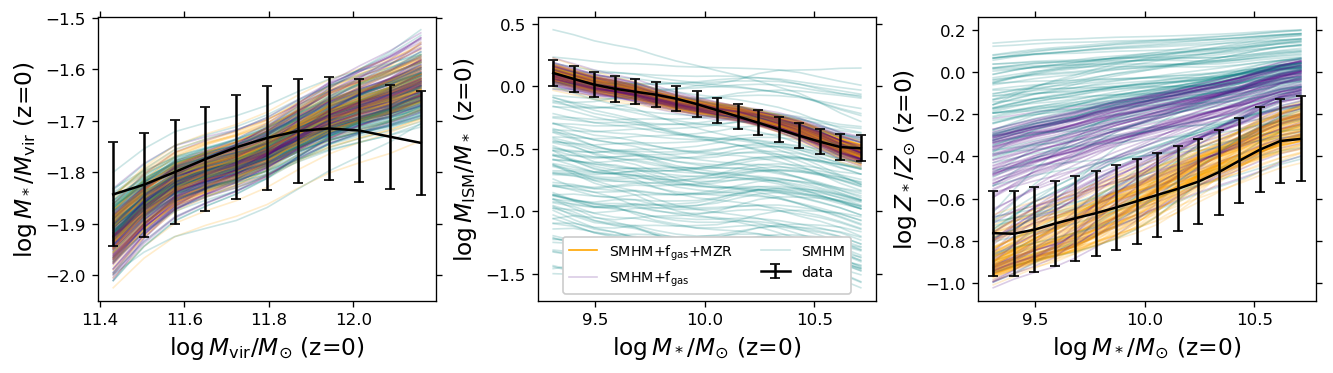

In [20]:
visualization.numpyro_plots.posterior_predictive_checks('/mnt/ceph/users/vpandya/sapphire_outputs/',
                                  'numpyro_manga_chain%s_%s_fixsmhm.npz',None)

In [21]:
### read in obs data
# WARNING: sapphire needs to be refactored since loading this first screws up num_cpus for XLA 
from sapphire.utils import read_obs
obs_manga = read_obs.read_manga({'obs_path':'/mnt/ceph/users/vpandya/sapphire/data/obs/manga/obs_stats_manga.npz'})
obs_lit = read_obs.read_literature({'obs_path':'/mnt/ceph/users/vpandya/sapphire/data/obs/literature/'}) # behroozi SMHM

(<Figure size 1320x360 with 3 Axes>,
 array([<Axes: xlabel='$\\log M_{\\rm vir}/M_{\\odot}$ (z=0)', ylabel='$\\log M_*/M_{\\rm vir}$ (z=0)'>,
        <Axes: xlabel='$\\log M_*/M_{\\odot}$ (z=0)', ylabel='$\\log M_{\\rm ISM}/M_*$ (z=0)'>,
        <Axes: xlabel='$\\log M_*/M_{\\odot}$ (z=0)', ylabel='$\\log Z_*/Z_{\\odot}$ (z=0)'>],
       dtype=object))

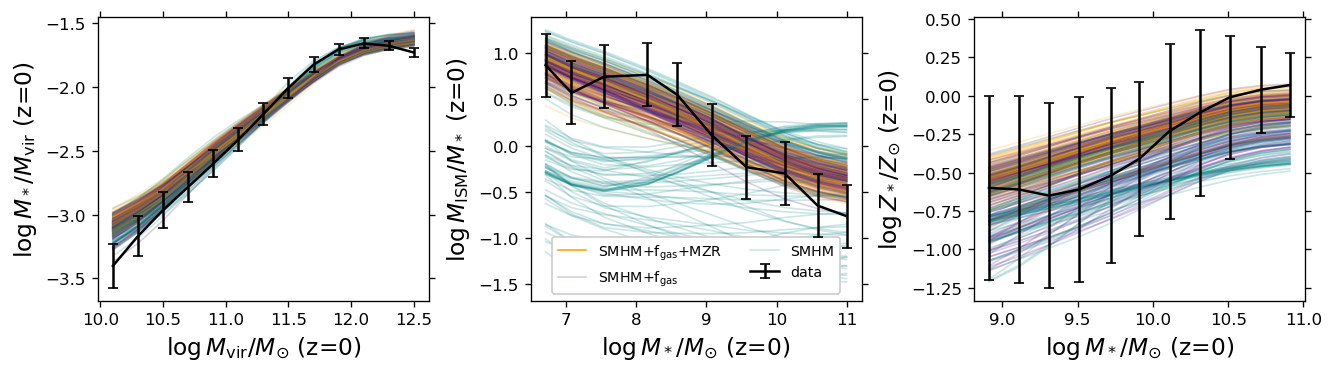

In [23]:
###  old literature (unrealistically large MZR and fgas errorbars)
visualization.numpyro_plots.posterior_predictive_checks('/mnt/ceph/users/vpandya/sapphire_outputs/',
                                  'numpyro_lit_chain%s_%s.npz',obs_lit)

In [24]:
obs_manga[0], obs_lit[0]

(Array([11.43128929, 11.50409867, 11.57690805, 11.64971742, 11.7225268 ,
        11.79533618, 11.86814556, 11.94095494, 12.01376431, 12.08657369,
        12.15938307], dtype=float64),
 Array([10.1, 10.3, 10.5, 10.7, 10.9, 11.1, 11.3, 11.5, 11.7, 11.9, 12.1,
        12.3, 12.5], dtype=float64))

# manual testing

In [1]:
%matplotlib inline 
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck15
from astropy.table import Table
from astropy import constants as const
from astropy import units as u
from glob import glob
import h5py 
from timeit import default_timer as timer
import multiprocess

import os, sys
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=50"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # for GPU 

from jax import config
config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax._src.third_party.scipy.interpolate import RegularGridInterpolator as jax_RegularGridInterpolator
from jax import jit, grad, vmap, pmap, debug, jvp, vjp, jacrev, jacfwd, make_jaxpr, hessian, value_and_grad
from jax_cosmo.scipy.interpolate import InterpolatedUnivariateSpline

from scipy.interpolate import InterpolatedUnivariateSpline as scipy_InterpolatedUnivariateSpline
from scipy.ndimage import gaussian_filter1d

from jax.experimental.ode import odeint
from jax.lax import fori_loop, while_loop
from jax.scipy.integrate import trapezoid

from diffrax import diffeqsolve, ODETerm, PIDController, SaveAt, Kvaerno3, Bosh3, Dopri5, Tsit5, DirectAdjoint, RecursiveCheckpointAdjoint, BacksolveAdjoint

from diffrax import backward_hermite_coefficients, CubicInterpolation

from functools import partial

from jax.random import PRNGKey, key

import numpyro
import numpyro.distributions as dist
from numpyro.examples.datasets import LYNXHARE, load_dataset
from numpyro.infer import MCMC, NUTS, Predictive, AIES, ESS

from jax.experimental import mesh_utils
from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh, PartitionSpec, PositionalSharding, NamedSharding

import optax

import arviz as az
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from chainconsumer import Chain, ChainConsumer, make_sample, PlotConfig, Truth, ChainConfig
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

In [5]:
output_path = '/mnt/ceph/users/vpandya/sapphire_outputs'
basestr = 'numpyro_manga_chain%s_%s_fixsmhm.npz'

In [6]:
##### load posterior predictive samples

params_free = ["A_M","alpha0_M","A_E","alpha0_E","A_SF","alpha0_SF","A_Z","alpha0_Z"]

def get_samples(flag):
    ### loop over and store posterior samples from all 4 chains    
    # samples dataframes indexed by int for chain_num for Gelman-Rubin statistic 
    chain_samples = {}
    
    # TO DO: generalize depending on actual # of chains
    for cnum in range(0,4):
    
        # TO DO: generalize this beyond numpyro_manga_chain%s_%s.npz
        fname = os.path.join(output_path,'outputs',basestr%(cnum,flag))
        npz_nuts = jnp.load(fname,allow_pickle=True)
    
        samples_dict = {k: npz_nuts['samples'].item()[k] for k in params_free}
        samples_df = pd.DataFrame(samples_dict)
        chain_samples[cnum] = samples_df
    
    # combine the different chains' posterior samples
    samples_df = pd.concat(chain_samples.values(), ignore_index=True)  

    return samples_df

samples_df111 = get_samples('111')
samples_df110 = get_samples('110')
samples_df100 = get_samples('100')

In [7]:
samples_df111

,A_M,alpha0_M,A_E,alpha0_E,A_SF,alpha0_SF,A_Z,alpha0_Z
0,-1.599962,-1.536016,-0.164381,-0.136113,0.872148,-1.896280,-0.115038,-0.116256
1,-0.313342,-0.271188,-0.509442,-0.117013,0.840257,-1.071025,-0.150927,-0.895461
2,-0.295514,-0.134237,-0.521775,-0.286914,0.846138,-1.658843,-0.149221,-1.122971
3,-1.316277,-0.397941,-0.398631,-0.634923,0.818946,-1.746845,-0.105705,-0.157325
4,-1.871203,-1.049036,-0.297973,-0.313225,0.803956,-1.442356,-0.087620,-0.215034
...,...,...,...,...,...,...,...,...
7995,-1.103233,-1.217639,-0.366601,-0.469428,0.785533,-1.742464,-0.035689,-1.578996
7996,-1.496063,-1.472467,-0.345466,-0.459702,0.771483,-1.758492,-0.028814,-1.532352
7997,0.025325,-0.586909,-0.518704,-0.087980,0.915813,-1.448594,-0.263543,-0.496233
7998,-0.309046,-1.901758,-0.528305,-0.097423,0.868720,-1.713520,-0.096194,-1.427547


In [8]:
samples_df111.loc[0].to_dict()

{'A_M': -1.599961517273028,
 'alpha0_M': -1.5360156894288848,
 'A_E': -0.16438060853795822,
 'alpha0_E': -0.13611346270349567,
 'A_SF': 0.8721476070080322,
 'alpha0_SF': -1.896280286987825,
 'A_Z': -0.11503805812928869,
 'alpha0_Z': -0.11625625070242074}

In [9]:
# easiest to re-read in the config that determined ODE model setup
# this should've been same regardless of inference constraints
from sapphire.utils import read_config
config = read_config.get({'path_config':'/mnt/ceph/users/vpandya/sapphire/scripts/config.yaml'})

### now modify for single run
config['runtype'] = 'single'

# overwrite default params to a random row from posterior samples
config['params_fixed_astro'] = {**config['params_fixed_astro'],**samples_df111.loc[0].to_dict()}

config['params_fixed_astro']

{'alpha_n': -1.5,
 'alpha_T': 0.0,
 'f_recycle': 0.4,
 'yZ': 0.02,
 'A_M': -1.599961517273028,
 'alpha0_M': -1.5360156894288848,
 'A_E': -0.16438060853795822,
 'alpha0_E': -0.13611346270349567,
 'A_SF': 0.8721476070080322,
 'alpha0_SF': -1.896280286987825,
 'A_Z': -0.11503805812928869,
 'alpha0_Z': -0.11625625070242074,
 'alphaz_M': 0.0,
 'beta_M': 0.0,
 'alphaz_E': 0.0,
 'beta_E': 0.0,
 'alphaz_SF': 0.0,
 'beta_SF': -0.7,
 'alphaz_Z': 0.0,
 'beta_Z': 0.0}

In [10]:
import os
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=%s"%config['num_cpus']

import sapphire

In [11]:
out_sapphire = sapphire.run(config)
sol = out_sapphire[0]

reading /mnt/ceph/users/vpandya/sapphire/scripts/config.yaml

your full sapphire config:

{   'Nbatch': 1000,
    'chain_num': 0,
    'coolfunc': 'sd93',
    'flag_fgas': 1,
    'flag_mzr': 1,
    'flag_smhm': 1,
    'inference_config': {   'Nadam': 3,
                            'adam_logL': 'numpyro',
                            'engine': 'nuts',
                            'fit_mock': False,
                            'fit_obs': True,
                            'num_samples': 10000,
                            'num_warmup': 2000,
                            'random_mock': True,
                            'write_output': True},
    'model': 'pandya23',
    'num_cpus': 50,
    'obs_err_fgas': 0.0,
    'obs_err_mzr': 0.0,
    'obs_err_smhm': 0.0,
    'obs_name': 'lit',
    'obs_path': '/mnt/ceph/users/vpandya/sapphire/data/obs/literature/',
    'output_path': '/mnt/ceph/users/vpandya/sapphire_outputs/',
    'output_prefix': 'numpyro_{obs_name}_chain{chain_num}',
    'output_suffix':

In [12]:
from sapphire.summaries import gaussian_kernel_regression as gkr

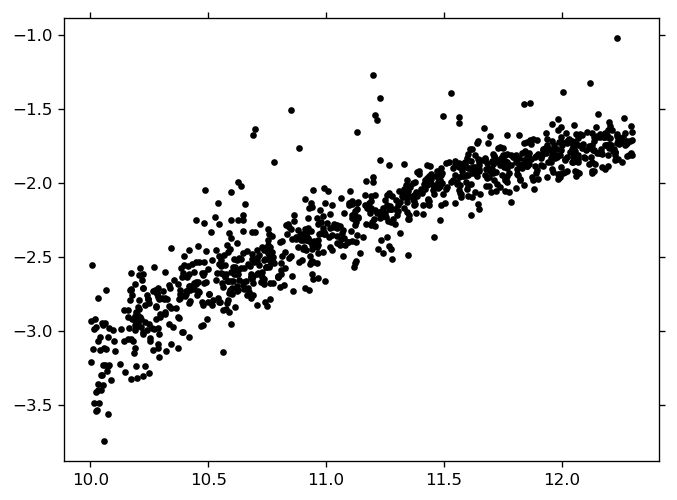

In [15]:
props = gkr.extract_quantities(sol)
z0_Mvir, z0_smhm, fail_flag, Nfail, z0_Mstar, z0_fgas, z0_mzr = props

plt.plot(z0_Mvir,z0_smhm,'k.')